# In this notebook
I model results to compare the uncertainty quantification between two models. These results demonstrate that we get better uncertainty quantification with the S-PLL approach.

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [3]:
test_df = pd.read_csv('../results/model_output/july2024.csv')
stations = np.unique(test_df[['lat', 'lon']].values, axis=0)

# Convert date to EST timezone
test_df['date'] = pd.to_datetime(test_df['date'])
test_df['date'] = test_df['date'].dt.tz_convert('America/New_York')

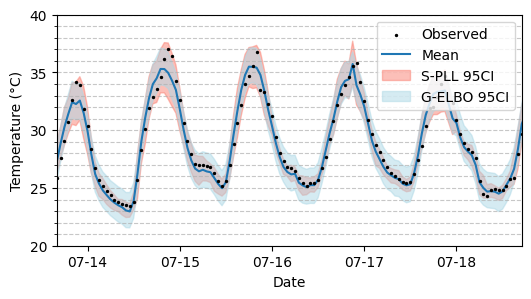

In [4]:
i = 14
station = stations[i, :]
station = test_df[(test_df['lat'] == station[0]) & (test_df['lon'] == station[1])]



plt.figure(figsize=(6,3))
plt.scatter(station['date'], station['tempAvg'], s=2, color='black', label='Observed', zorder=3)

plt.plot(station['date'], station['spll'], label='Mean')
plt.fill_between(station['date'], station['spll_lower'], station['spll_upper'], color='salmon', alpha=0.5, label='S-PLL 95CI')

# plt.plot(station['date'], station['gpll'], label='GPLL Est.')
plt.fill_between(station['date'], station['gpll'] - 1.96*np.sqrt(station['gpll_var']), station['gpll'] + 1.96*np.sqrt(station['gpll_var']), alpha=0.5, color='lightblue', label='G-ELBO 95CI')

start = 12*24
end = start + 24*5
plt.xlim(station['date'].iloc[start], station['date'].iloc[end])
plt.ylim(20, 40)
plt.legend()

# Change formatting of date to just be MM-DD
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

# Set major ticks to every 5 degrees with minor every 1 degree
plt.gca().yaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(5))
plt.gca().yaxis.set_minor_locator(plt.matplotlib.ticker.MultipleLocator(1))

plt.grid(axis='y', linestyle='--', alpha=0.7, which='both')
# plt.show()

plt.savefig('../figures/temperature_estimates.pdf', dpi=1000, bbox_inches='tight')

In [5]:
test_df['hour'] = test_df['date'].dt.hour

pll_am = test_df[test_df['hour'] == 6]['spll_var'].values
pll_pm = test_df[test_df['hour'] == 18]['spll_var'].values
elbo_am = test_df[test_df['hour'] == 6]['gpll_var'].values
elbo_pm = test_df[test_df['hour'] == 18]['gpll_var'].values

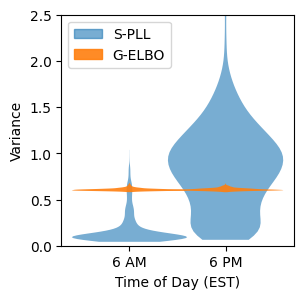

In [7]:
plt.figure(figsize=(3, 3))
parts = plt.violinplot([pll_am, pll_pm], positions=[0, 1], showextrema=False, widths=1.2)


# parts = plt.violinplot([six_am, six_pm], positions=[0, 1], showextrema=False, widths=0.8)

# Colors
colors = ["#1f77b4", "#ff7f0e"]
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor('C0')
    pc.set_alpha(0.6)
plt.ylim(0, 2.5)
parts = plt.violinplot([elbo_am, elbo_pm], positions=[0, 1], showextrema=False, widths=1.2)

for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor('C1')
    pc.set_alpha(0.9)

# plt.xticks([6, 12], ['6 AM', '6 PM'])
plt.xticks([0, 1], ["6 AM", "6 PM"])
# plt.
plt.ylabel('Variance')
plt.xlabel("Time of Day (EST)")
import matplotlib.patches as mpatches
label1 = mpatches.Patch(color='C0', label='S-PLL', alpha=0.6)
label2 = mpatches.Patch(color='C1', label='G-ELBO', alpha=0.9)

plt.legend(handles=[label1, label2])

plt.savefig('../figures/variance_time_of_day.pdf', dpi=1000, bbox_inches='tight')
# plt.show()